# EMA 21/13/8 Scalping Strategy — Crypto (H1 + M5)

This notebook is the **crypto** companion to `03_strategy03.ipynb` (forex). Strategy rules are the same; **pending-order distance uses a configurable tick size** suited to digital assets.

1. Load data from local cache (`./data/<symbol>/<timeframe>`)
2. Build EMA indicators (`21`, `13`, `8`)
3. Use `H1` as trend confirmation
4. On `M5`, place a pending stop beyond the last `5` candles high/low (`PENDING_OFFSET_TICKS` × `PIP_SIZE` price units)
5. Use `TP:SL = 1:1`
6. Expire pending orders after `60 minutes`
7. Backtest and save results under `./results/strategy03_crypto/...`

Reference video: https://www.youtube.com/watch?v=zhEukjCzXwM


In [147]:
# SECTION 1 - Imports and parameters
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

# === User parameters (crypto quotes) ===
SYMBOL = "ETHUSD"
# e.g. BTCUSD, ETHUSD, XRPUSD, BCHUSD, BNBUSD, SOLUSD, TRXUSD, DOGEUSD, LNKUSD, UNIUSD,
#  LTCUSD, ADAUSD, AVEUSD, AVXUSD ...
TF_ENTRY = "M5"
TF_TREND = "H1"

EMA_FAST = 8
EMA_MID = 13
EMA_SLOW = 21

LOOKBACK_BARS = 5
# Pending stop distance beyond swing = PENDING_OFFSET_TICKS * PIP_SIZE (price units).
PENDING_OFFSET_TICKS = 3.0
PENDING_EXPIRY_MIN = 60
RR = 1.0  # TP:SL = 1:1


def _default_crypto_tick(sym: str) -> float:
    """Rough defaults — set PIP_SIZE yourself if your data uses a different step."""
    u = sym.upper()
    if u.startswith("BTC"):
        return 1.0
    if u.startswith("ETH"):
        return 0.01
    if u.startswith(("XRP", "DOGE", "ADA")):
        return 0.0001
    if u.startswith(("BNB", "BCH", "LTC", "SOL")):
        return 0.01
    return 0.01


PIP_SIZE = _default_crypto_tick(SYMBOL)
# Backtest engine uses this name; value is tick/step size for crypto.
PENDING_OFFSET_PIPS = float(PENDING_OFFSET_TICKS)

START_BALANCE = 10000.0
RISK_PER_TRADE = 0.01

# Limit backtest/chart M5 history to the last BARS rows (trim applied in Section 4 after H1→M5 mapping).
# EMA + merge still see full loaded history first so rows inside the window are warmed up.
BARS = None  # e.g. 2000

print(
    f"Symbol={SYMBOL}, Trend={TF_TREND}, Entry={TF_ENTRY}, "
    f"PIP_SIZE(tick)={PIP_SIZE}, offset_ticks={PENDING_OFFSET_TICKS}, BARS={BARS}"
)


Symbol=ETHUSD, Trend=H1, Entry=M5, PIP_SIZE(tick)=0.01, offset_ticks=3.0, BARS=None


In [148]:
# SECTION 2 - Load data from cache: ./data/<symbol>/<timeframe>
def _standardize_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {
        "Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "volume",
        "o": "open", "h": "high", "l": "low", "c": "close", "v": "volume",
        "tick_volume": "volume",
    }
    df = df.rename(columns=rename_map)

    if not isinstance(df.index, pd.DatetimeIndex):
        dt_cols = [c for c in ["time", "datetime", "date", "timestamp"] if c in df.columns]
        if dt_cols:
            dt_col = dt_cols[0]
            df[dt_col] = pd.to_datetime(df[dt_col], utc=False, errors="coerce")
            df = df.set_index(dt_col)
        else:
            first = df.columns[0]
            maybe_dt = pd.to_datetime(df[first], utc=False, errors="coerce")
            if maybe_dt.notna().mean() > 0.8:
                df[first] = maybe_dt
                df = df.set_index(first)

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Could not infer datetime index from cache file.")

    need = ["open", "high", "low", "close"]
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise ValueError(f"Missing OHLC columns: {miss}")

    if "volume" not in df.columns:
        df["volume"] = 1.0

    out = df[["open", "high", "low", "close", "volume"]].copy()
    out = out.sort_index().dropna()
    return out


def load_cached_timeframe(symbol: str, timeframe: str, base_dir: str = "./data") -> pd.DataFrame:
    folder = Path(base_dir) / symbol / timeframe
    if not folder.exists():
        # fallback to lowercase timeframe folders if needed
        alt = Path(base_dir) / symbol / timeframe.lower()
        if alt.exists():
            folder = alt
        else:
            raise FileNotFoundError(f"Cache folder not found: {folder}")

    files = sorted(
        [*folder.glob("*.parquet"), *folder.glob("*.csv")],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not files:
        raise FileNotFoundError(f"No cache file found in {folder}")

    path = files[0]
    df = pd.read_parquet(path) if path.suffix.lower() == ".parquet" else pd.read_csv(path)
    df = _standardize_ohlcv(df)
    print(f"Loaded {len(df):,} rows from {path}")
    return df

m5 = load_cached_timeframe(SYMBOL, TF_ENTRY)
h1 = load_cached_timeframe(SYMBOL, TF_TREND)

display(m5.head(3))
display(h1.head(3))

Loaded 100,000 rows from data\ETHUSD\M5\ohlcv.csv
Loaded 8,000 rows from data\ETHUSD\H1\ohlcv.csv


,open,high,low,close,volume
time,,,,,
2025-05-24 10:30:00+00:00,2553.75,2553.75,2547.89,2548.35,174
2025-05-24 10:35:00+00:00,2548.47,2550.06,2545.78,2545.78,152
2025-05-24 10:40:00+00:00,2545.87,2547.59,2543.56,2545.98,144


,open,high,low,close,volume
time,,,,,
2025-06-07 11:00:00+00:00,2485.80,2486.70,2476.40,2478.12,1315
2025-06-07 12:00:00+00:00,2478.24,2484.80,2477.42,2480.28,1060
2025-06-07 13:00:00+00:00,2480.50,2491.08,2478.96,2489.17,1389


In [149]:
# SECTION 3 - Build EMA 21/13/8 on both timeframes
for df in (m5, h1):
    df[f"ema_{EMA_FAST}"] = df["close"].ewm(span=EMA_FAST, adjust=False).mean()
    df[f"ema_{EMA_MID}"] = df["close"].ewm(span=EMA_MID, adjust=False).mean()
    df[f"ema_{EMA_SLOW}"] = df["close"].ewm(span=EMA_SLOW, adjust=False).mean()

print("EMA columns added.")
display(h1[["close", f"ema_{EMA_FAST}", f"ema_{EMA_MID}", f"ema_{EMA_SLOW}"]].tail(5))

EMA columns added.


,close,ema_8,ema_13,ema_21
time,,,,
2026-05-09 09:00:00+00:00,2310.39,2308.973568,2306.323942,2303.018356
2026-05-09 10:00:00+00:00,2310.75,2309.368331,2306.956236,2303.721233
2026-05-09 11:00:00+00:00,2313.41,2310.266480,2307.878202,2304.602030
2026-05-09 12:00:00+00:00,2309.46,2310.087262,2308.104173,2305.043664
2026-05-09 13:00:00+00:00,2309.59,2309.976759,2308.316434,2305.456967


In [150]:
# SECTION 4 - H1 trend direction confirmation
# Bull trend: EMA8 > EMA13 > EMA21 and close > EMA21
# Bear trend: EMA8 < EMA13 < EMA21 and close < EMA21

h1_sig = h1.copy()

h1_sig["trend"] = "flat"
h1_sig.loc[
    (h1_sig[f"ema_{EMA_FAST}"] > h1_sig[f"ema_{EMA_MID}"]) &
    (h1_sig[f"ema_{EMA_MID}"] > h1_sig[f"ema_{EMA_SLOW}"]) &
    (h1_sig["close"] > h1_sig[f"ema_{EMA_SLOW}"]),
    "trend"
] = "bull"

h1_sig.loc[
    (h1_sig[f"ema_{EMA_FAST}"] < h1_sig[f"ema_{EMA_MID}"]) &
    (h1_sig[f"ema_{EMA_MID}"] < h1_sig[f"ema_{EMA_SLOW}"]) &
    (h1_sig["close"] < h1_sig[f"ema_{EMA_SLOW}"]),
    "trend"
] = "bear"

# Map H1 trend onto M5 timeline
m5_ctx = pd.merge_asof(
    m5.sort_index(),
    h1_sig[["trend", f"ema_{EMA_FAST}", f"ema_{EMA_MID}", f"ema_{EMA_SLOW}"]].sort_index(),
    left_index=True,
    right_index=True,
    direction="backward",
    suffixes=("", "_h1")
)

print(m5_ctx["trend"].value_counts(dropna=False))

if BARS is not None:
    _bars_n = int(BARS)
    if _bars_n > 0:
        _before = len(m5_ctx)
        m5_ctx = m5_ctx.iloc[-_bars_n:].copy()
        m5 = m5.loc[m5_ctx.index].copy()
        if _before > _bars_n:
            print(f"BARS={_bars_n}: trimmed M5 window {_before} -> {len(m5_ctx)} rows")
        if len(m5_ctx) < LOOKBACK_BARS + 2:
            print(
                f"Warning: only {len(m5_ctx)} M5 bars after trim; "
                f"strategy loop starts after LOOKBACK_BARS={LOOKBACK_BARS}."
            )


display(m5_ctx[["close", "trend"]].tail(8))

trend
bull    38413
bear    36744
flat    20805
NaN      4038
Name: count, dtype: int64


,close,trend
time,,
2026-05-09 15:25:00+00:00,2313.25,bull
2026-05-09 15:30:00+00:00,2311.72,bull
2026-05-09 15:35:00+00:00,2310.74,bull
2026-05-09 15:40:00+00:00,2311.41,bull
2026-05-09 15:45:00+00:00,2312.78,bull
2026-05-09 15:50:00+00:00,2312.46,bull
2026-05-09 15:55:00+00:00,2312.66,bull
2026-05-09 16:00:00+00:00,2312.69,bull


In [151]:
# SECTION 5 - Strategy engine (pending stop orders + expiry + TP/SL)
def run_backtest(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    data = data.copy().sort_index()

    expiry_bars = max(1, int(PENDING_EXPIRY_MIN / 5))  # M5 -> 12 bars for 60m

    trades = []
    balance = START_BALANCE
    equity_curve = []

    pending = None   # dict or None
    position = None  # dict or None

    for i in range(LOOKBACK_BARS, len(data)):
        idx = data.index[i]
        row = data.iloc[i]

        # mark-to-market equity (simple close-based)
        floating = 0.0
        if position is not None:
            if position["side"] == "buy":
                floating = (row["close"] - position["entry"]) * position["qty"]
            else:
                floating = (position["entry"] - row["close"]) * position["qty"]
        equity_curve.append((idx, balance + floating))

        # 1) manage open position first
        if position is not None:
            hit_sl = False
            hit_tp = False

            if position["side"] == "buy":
                hit_sl = row["low"] <= position["sl"]
                hit_tp = row["high"] >= position["tp"]
            else:
                hit_sl = row["high"] >= position["sl"]
                hit_tp = row["low"] <= position["tp"]

            if hit_sl or hit_tp:
                # conservative fill priority: SL first if both touched in same candle
                exit_price = position["sl"] if hit_sl else position["tp"]
                pnl = (exit_price - position["entry"]) * position["qty"]
                if position["side"] == "sell":
                    pnl = -pnl

                balance += pnl
                trades.append({
                    "entry_time": position["entry_time"],
                    "exit_time": idx,
                    "side": position["side"],
                    "entry": position["entry"],
                    "sl": position["sl"],
                    "tp": position["tp"],
                    "exit": exit_price,
                    "qty": position["qty"],
                    "pnl": pnl,
                    "balance_after": balance,
                    "result": "win" if pnl > 0 else "loss",
                })
                position = None
            continue

        # 2) manage pending order expiry / trigger
        if pending is not None:
            age = i - pending["created_i"]
            if age > expiry_bars:
                pending = None
            else:
                if pending["side"] == "buy":
                    if row["high"] >= pending["entry"]:
                        position = {
                            "side": "buy",
                            "entry": pending["entry"],
                            "sl": pending["sl"],
                            "tp": pending["tp"],
                            "qty": pending["qty"],
                            "entry_time": idx,
                        }
                        pending = None
                else:
                    if row["low"] <= pending["entry"]:
                        position = {
                            "side": "sell",
                            "entry": pending["entry"],
                            "sl": pending["sl"],
                            "tp": pending["tp"],
                            "qty": pending["qty"],
                            "entry_time": idx,
                        }
                        pending = None

        # 3) if free, place new pending order based on trend and last 5 candles
        if pending is None and position is None:
            window = data.iloc[i-LOOKBACK_BARS:i]
            hh = window["high"].max()
            ll = window["low"].min()

            trend = row.get("trend", "flat")
            offset = PENDING_OFFSET_PIPS * PIP_SIZE

            if trend == "bull":
                entry = hh + offset
                sl = ll - offset
                risk_per_unit = max(entry - sl, 1e-12)
                tp = entry + RR * risk_per_unit
                risk_cash = balance * RISK_PER_TRADE
                qty = risk_cash / risk_per_unit

                pending = {
                    "side": "buy",
                    "entry": float(entry),
                    "sl": float(sl),
                    "tp": float(tp),
                    "qty": float(qty),
                    "created_i": i,
                }

            elif trend == "bear":
                entry = ll - offset
                sl = hh + offset
                risk_per_unit = max(sl - entry, 1e-12)
                tp = entry - RR * risk_per_unit
                risk_cash = balance * RISK_PER_TRADE
                qty = risk_cash / risk_per_unit

                pending = {
                    "side": "sell",
                    "entry": float(entry),
                    "sl": float(sl),
                    "tp": float(tp),
                    "qty": float(qty),
                    "created_i": i,
                }

    trades_df = pd.DataFrame(trades)
    eq = pd.Series({t: v for t, v in equity_curve}).sort_index()
    return trades_df, eq

trades_df, equity_curve = run_backtest(m5_ctx)
print(f"Total trades: {len(trades_df)}")
display(trades_df.head(10))

Total trades: 2144


,entry_time,exit_time,side,entry,sl,tp,exit,qty,pnl,balance_after,result
0,2025-06-07 12:15:00+00:00,2025-06-07 13:20:00+00:00,buy,2482.89,2476.37,2489.41,2489.41,15.337423,100.000000,10100.000000,win
1,2025-06-07 13:30:00+00:00,2025-06-07 15:35:00+00:00,buy,2489.78,2478.93,2500.63,2500.63,9.308756,101.000000,10201.000000,win
2,2025-06-07 15:45:00+00:00,2025-06-07 16:00:00+00:00,buy,2500.70,2488.55,2512.85,2488.55,8.395885,-102.010000,10098.990000,loss
3,2025-06-07 16:15:00+00:00,2025-06-07 19:10:00+00:00,buy,2503.12,2486.95,2519.29,2519.29,6.245510,100.989900,10199.979900,win
4,2025-06-07 21:00:00+00:00,2025-06-07 21:20:00+00:00,buy,2508.17,2502.51,2513.83,2513.83,18.021166,101.999799,10301.979699,win
5,2025-06-07 21:30:00+00:00,2025-06-08 01:30:00+00:00,buy,2515.53,2501.79,2529.27,2529.27,7.497802,103.019797,10404.999496,win
6,2025-06-08 07:30:00+00:00,2025-06-08 07:45:00+00:00,buy,2509.43,2505.47,2513.39,2513.39,26.275251,104.049995,10509.049491,win
7,2025-06-08 09:15:00+00:00,2025-06-08 12:15:00+00:00,buy,2510.45,2504.07,2516.83,2504.07,16.471864,-105.090495,10403.958996,loss
8,2025-06-08 19:05:00+00:00,2025-06-08 19:10:00+00:00,buy,2511.37,2506.07,2516.67,2516.67,19.630111,104.039590,10507.998586,win
9,2025-06-08 19:20:00+00:00,2025-06-08 20:05:00+00:00,buy,2517.27,2506.07,2528.47,2528.47,9.382142,105.079986,10613.078572,win


In [152]:
# SECTION 6 - Backtest metrics (pilot result numbers)
def max_drawdown_pct(equity: pd.Series | None) -> float:
    """Peak-to-trough drawdown as % of running peak equity."""
    if equity is None or len(equity) < 2:
        return 0.0
    eq = pd.Series(equity).astype(float).dropna()
    if eq.empty:
        return 0.0
    peak = eq.cummax()
    dd = (eq - peak) / peak.replace(0, np.nan)
    return float(abs(dd.min()) * 100.0)


def summarize_results(
    trades: pd.DataFrame,
    start_balance: float,
    equity: pd.Series | None = None,
) -> pd.DataFrame:
    if trades.empty:
        return pd.DataFrame([{
            "trades": 0,
            "win_rate_%": 0.0,
            "net_pnl": 0.0,
            "avg_pnl": 0.0,
            "profit_factor": 0.0,
            "max_drawdown_%": round(max_drawdown_pct(equity), 2),
            "start_balance": start_balance,
            "end_balance": start_balance,
            "return_%": 0.0,
        }])

    wins = trades[trades["pnl"] > 0]["pnl"]
    losses = trades[trades["pnl"] < 0]["pnl"]

    gross_profit = wins.sum() if not wins.empty else 0.0
    gross_loss = abs(losses.sum()) if not losses.empty else 0.0
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

    end_balance = trades["balance_after"].iloc[-1]
    result = {
        "trades": int(len(trades)),
        "win_rate_%": round((trades["pnl"] > 0).mean() * 100, 2),
        "net_pnl": round(trades["pnl"].sum(), 2),
        "avg_pnl": round(trades["pnl"].mean(), 2),
        "profit_factor": round(float(profit_factor), 3) if pd.notna(profit_factor) else np.nan,
        "max_drawdown_%": round(max_drawdown_pct(equity), 2),
        "start_balance": round(start_balance, 2),
        "end_balance": round(float(end_balance), 2),
        "return_%": round(((end_balance / start_balance) - 1) * 100, 2),
    }
    return pd.DataFrame([result])


# Trade columns: price difference (exit - entry) and running sum of pnl (last column)
if not trades_df.empty:
    trades_df = trades_df.copy()
    trades_df["exit_minus_entry"] = trades_df["exit"] - trades_df["entry"]
    trades_df["cumulative_pnl"] = trades_df["pnl"].cumsum()
    _base_cols = [c for c in trades_df.columns if c not in ("exit_minus_entry", "cumulative_pnl")]
    trades_df = trades_df[_base_cols + ["exit_minus_entry", "cumulative_pnl"]]

summary = summarize_results(trades_df, START_BALANCE, equity_curve)
display(summary)

if not trades_df.empty:
    display(trades_df.tail(10))

,trades,win_rate_%,net_pnl,avg_pnl,profit_factor,max_drawdown_%,start_balance,end_balance,return_%
0,2144,59.75,577290.2,269.26,1.446,13.79,10000.0,587290.2,5772.9


,entry_time,exit_time,side,entry,sl,tp,exit,qty,pnl,balance_after,result,exit_minus_entry,cumulative_pnl
2134,2026-05-08 15:45:00+00:00,2026-05-08 16:10:00+00:00,sell,2285.14,2299.36,2270.92,2270.92,421.557183,5994.543148,605448.857936,win,-14.22,595448.857936
2135,2026-05-08 16:25:00+00:00,2026-05-08 17:15:00+00:00,sell,2270.52,2285.43,2255.61,2285.43,406.068986,-6054.488579,599394.369356,loss,14.91,589394.369356
2136,2026-05-08 17:30:00+00:00,2026-05-08 18:55:00+00:00,sell,2270.25,2289.10,2251.40,2289.10,317.981098,-5993.943694,593400.425663,loss,18.85,583400.425663
2137,2026-05-09 00:20:00+00:00,2026-05-09 01:00:00+00:00,buy,2306.61,2301.03,2312.19,2312.19,1063.441623,5934.004257,599334.429919,win,5.58,589334.429919
2138,2026-05-09 03:20:00+00:00,2026-05-09 04:10:00+00:00,buy,2305.10,2300.36,2309.84,2309.84,1264.418629,5993.344299,605327.774219,win,4.74,595327.774219
2139,2026-05-09 04:30:00+00:00,2026-05-09 05:30:00+00:00,buy,2309.89,2303.36,2316.42,2316.42,926.995060,6053.277742,611381.051961,win,6.53,601381.051961
2140,2026-05-09 06:20:00+00:00,2026-05-09 06:30:00+00:00,buy,2316.64,2310.76,2322.52,2310.76,1039.763694,-6113.810520,605267.241441,loss,-5.88,595267.241441
2141,2026-05-09 07:05:00+00:00,2026-05-09 07:40:00+00:00,buy,2317.31,2309.55,2325.07,2309.55,779.983559,-6052.672414,599214.569027,loss,-7.76,589214.569027
2142,2026-05-09 08:40:00+00:00,2026-05-09 09:50:00+00:00,buy,2314.63,2308.65,2320.61,2308.65,1002.031052,-5992.145690,593222.423337,loss,-5.98,583222.423337
2143,2026-05-09 11:05:00+00:00,2026-05-09 12:15:00+00:00,buy,2313.23,2309.89,2316.57,2309.89,1776.115040,-5932.224233,587290.199103,loss,-3.34,577290.199103


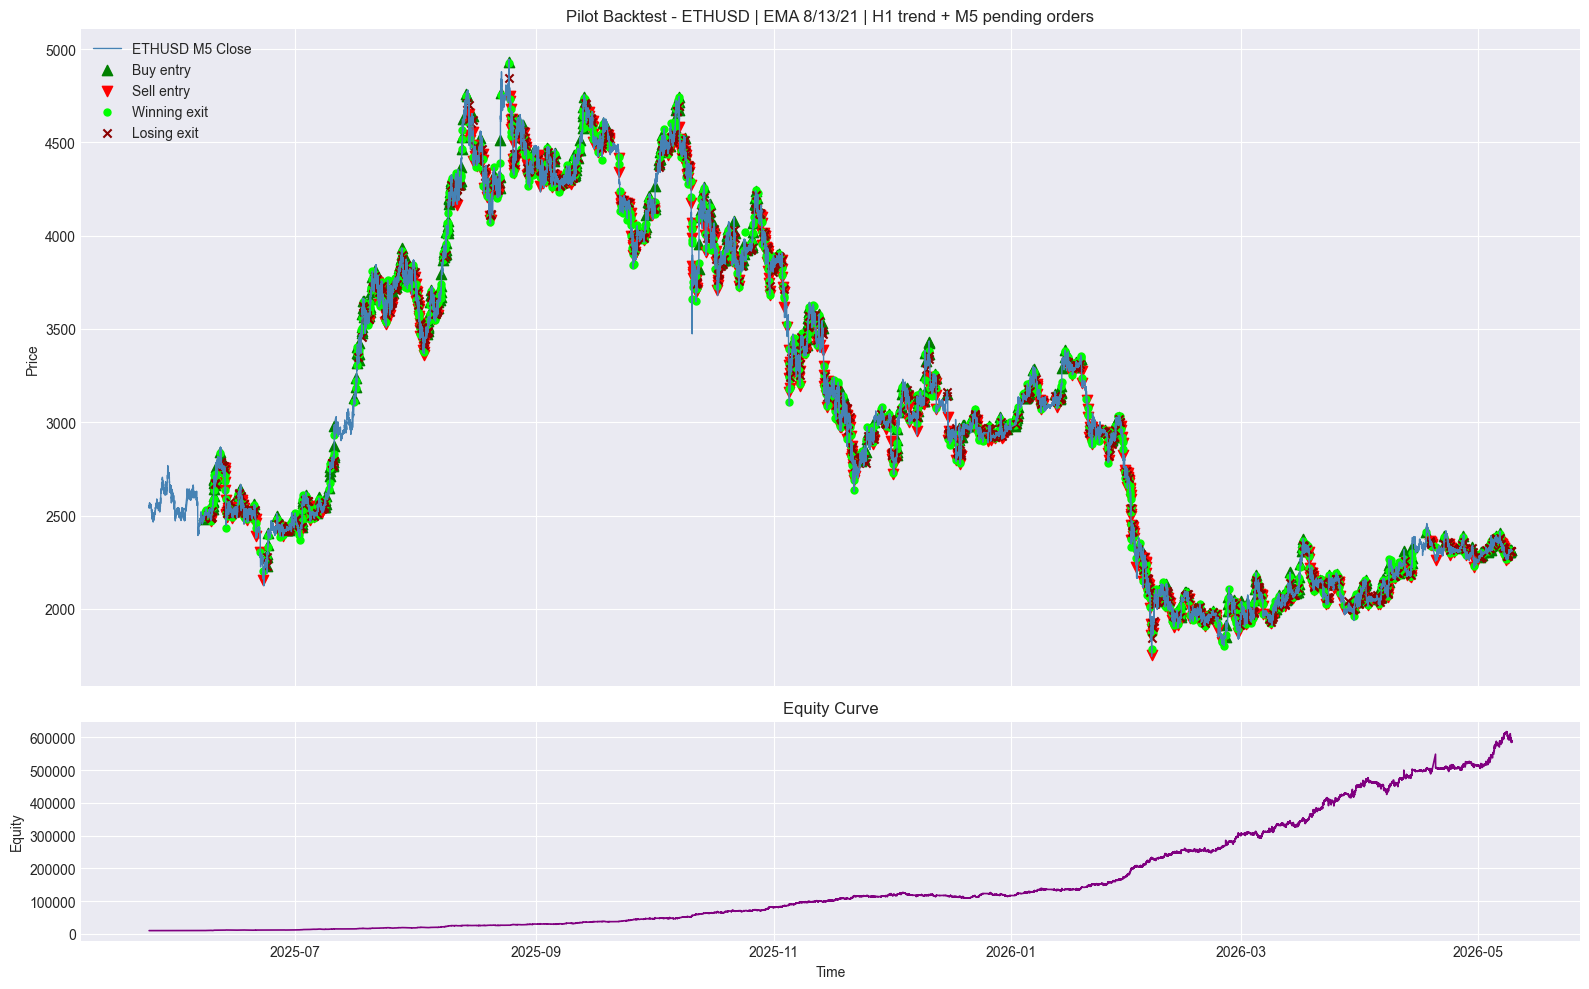

In [153]:
# SECTION 7 - Pilot result chart (price + entries/exits + equity)
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax_price, ax_eq = axes

# price line (you can replace with candlestick later)
ax_price.plot(m5_ctx.index, m5_ctx["close"], label=f"{SYMBOL} M5 Close", color="steelblue", linewidth=1.0)

if not trades_df.empty:
    buys = trades_df[trades_df["side"] == "buy"]
    sells = trades_df[trades_df["side"] == "sell"]

    ax_price.scatter(buys["entry_time"], buys["entry"], marker="^", color="green", s=55, label="Buy entry")
    ax_price.scatter(sells["entry_time"], sells["entry"], marker="v", color="red", s=55, label="Sell entry")

    win_trades = trades_df[trades_df["pnl"] > 0]
    loss_trades = trades_df[trades_df["pnl"] <= 0]

    ax_price.scatter(win_trades["exit_time"], win_trades["exit"], marker="o", color="lime", s=25, label="Winning exit")
    ax_price.scatter(loss_trades["exit_time"], loss_trades["exit"], marker="x", color="darkred", s=35, label="Losing exit")

ax_price.set_title(f"Pilot Backtest - {SYMBOL} | EMA {EMA_FAST}/{EMA_MID}/{EMA_SLOW} | H1 trend + M5 pending orders")
ax_price.set_ylabel("Price")
ax_price.legend(loc="upper left")

if equity_curve is not None and len(equity_curve) > 0:
    ax_eq.plot(equity_curve.index, equity_curve.values, color="purple", linewidth=1.2)
ax_eq.set_title("Equity Curve")
ax_eq.set_ylabel("Equity")
ax_eq.set_xlabel("Time")

plt.tight_layout()
plt.show()

## Notes and tuning ideas

- Same structure as the forex notebook (`03_strategy03.ipynb`); results save under `results/strategy03_crypto/` so runs do not overwrite FX outputs.
- **Tick size**: If pending orders sit too tight or too wide versus your cached OHLC, assign `PIP_SIZE` explicitly after the helper (must match your data’s minimum price step).
- For stricter trend filter, require H1 candle close above/below all EMAs.
- For lower trade frequency, increase `LOOKBACK_BARS` from `5` to `8–12`.
- For different risk profile, change `RISK_PER_TRADE` and `RR`.

Video reference: https://www.youtube.com/watch?v=zhEukjCzXwM


In [154]:
# SECTION 8 - Save results to folder
# Crypto variant output path:
# ./results/strategy03_crypto/{{symbol}}/{{timeframe}}/merics.csv
# ./results/strategy03_crypto/{{symbol}}/{{timeframe}}/trades.csv

RESULT_BASE = Path("./results") / "strategy03_crypto"
RESULT_SYMBOL = SYMBOL
RESULT_TIMEFRAME = TF_ENTRY  # you asked path with {{timeframe}}

result_dir = RESULT_BASE / RESULT_SYMBOL / RESULT_TIMEFRAME
result_dir.mkdir(parents=True, exist_ok=True)

metrics_path = result_dir / "merics.csv"   # kept exact requested filename
trades_path = result_dir / "trades.csv"

summary.to_csv(metrics_path, index=False)

if trades_df is None or trades_df.empty:
    pd.DataFrame(columns=[
        "entry_time", "exit_time", "side", "entry", "sl", "tp", "exit",
        "qty", "pnl", "balance_after", "result",
        "exit_minus_entry", "cumulative_pnl",
    ]).to_csv(trades_path, index=False)
else:
    trades_df.to_csv(trades_path, index=False)

print(f"Created folder: {result_dir}")
print(f"Saved metrics: {metrics_path}")
print(f"Saved trades : {trades_path}")


Created folder: results\strategy03_crypto\ETHUSD\M5
Saved metrics: results\strategy03_crypto\ETHUSD\M5\merics.csv
Saved trades : results\strategy03_crypto\ETHUSD\M5\trades.csv


In [155]:
# SECTION 9 - Interactive Plotly chart (last 1500 M5 bars + last 5 entries + RSI)
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

N_LAST_TRADES = 5
RSI_PERIOD = 14
BAR_TAIL = 1500


def compute_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = (-delta.clip(upper=0))
    avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


ind = m5_ctx.sort_index().reset_index()
first_col = ind.columns[0]
if first_col != "time":
    ind = ind.rename(columns={first_col: "time"})
ind = ind.rename(columns={
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
})

ind["ema_fast"] = ind[f"ema_{EMA_FAST}"]
ind["ema_medium"] = ind[f"ema_{EMA_MID}"]
ind["ema_slow"] = ind[f"ema_{EMA_SLOW}"]
ind["rsi"] = compute_rsi(ind["Close"], RSI_PERIOD)

tail = ind.tail(BAR_TAIL)

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.65, 0.35],
    vertical_spacing=0.04,
)

fig.add_trace(
    go.Candlestick(
        x=tail["time"],
        open=tail["Open"],
        high=tail["High"],
        low=tail["Low"],
        close=tail["Close"],
        name=f"{SYMBOL} M5",
    ),
    row=1,
    col=1,
)

for ema, color in zip(
    ["ema_fast", "ema_medium", "ema_slow"],
    ["#00cc96", "#636efa", "#ef553b"],
):
    fig.add_trace(
        go.Scatter(
            x=tail["time"],
            y=tail[ema],
            name=ema,
            line=dict(color=color, width=1),
        ),
        row=1,
        col=1,
    )

fig.add_trace(
    go.Scatter(
        x=tail["time"],
        y=tail["rsi"],
        name="RSI",
        line=dict(color="#ab63fa"),
    ),
    row=2,
    col=1,
)

fig.add_hline(y=51, line_dash="dot", row=2, col=1)
fig.add_hline(y=49, line_dash="dot", row=2, col=1)

if trades_df is not None and not trades_df.empty:
    last5 = trades_df.tail(N_LAST_TRADES).copy()
    et = pd.to_datetime(last5["entry_time"], utc=False, errors="coerce")
    sym_mrk = [
        "triangle-up" if str(s).lower() == "buy" else "triangle-down"
        for s in last5["side"]
    ]
    cols = ["#2ca02c" if str(s).lower() == "buy" else "#d62728" for s in last5["side"]]
    hover_lines = []
    for _, r in last5.iterrows():
        parts = [
            f"<b>{str(r['side']).upper()}</b>",
            f"entry {float(r['entry']):.5f}",
            f"SL {float(r['sl']):.5f}  TP {float(r['tp']):.5f}",
            f"exit {float(r['exit']):.5f}  pnl {float(r['pnl']):.2f}  {r.get('result', '')}",
        ]
        if "cumulative_pnl" in last5.columns and pd.notna(r.get("cumulative_pnl")):
            parts.append(f"cumulative_pnl {float(r['cumulative_pnl']):.2f}")
        hover_lines.append("<br>".join(parts))

    fig.add_trace(
        go.Scatter(
            x=et,
            y=last5["entry"].astype(float),
            mode="markers",
            marker=dict(size=13, color=cols, symbol=sym_mrk, line=dict(width=1, color="white")),
            name=f"Last {N_LAST_TRADES} entries",
            text=hover_lines,
            hovertemplate="%{text}<extra></extra>",
        ),
        row=1,
        col=1,
    )

fig.update_layout(
    height=650,
    xaxis_rangeslider_visible=False,
    template="plotly_dark",
    title=dict(text=f"{SYMBOL} — tail({BAR_TAIL}) M5 bars + last {N_LAST_TRADES} entries (hover markers)"),
)

fig.show()


## SECTION 10 — Four-week (28-day) metrics

Trades are grouped into consecutive **28-day** windows from the **first exit** (UTC, midnight-normalized anchor). Assignment uses each trade’s **`exit_time`**. **`start_balance`** / **`end_balance`** chain forward from **`START_BALANCE`** like a month-by-month account simulation (windows with no trades keep the same balance).


In [156]:
# SECTION 10 — Four-week (28-day) metrics
from IPython.display import display

PERIOD_DAYS = 28  # four weeks per bucket


def _four_week_metrics(trades: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "period_idx",
        "period_start",
        "period_end_inclusive",
        "trades",
        "win_rate_%",
        "net_pnl",
        "avg_pnl",
        "profit_factor",
        "start_balance",
        "end_balance",
        "return_%",
    ]
    empty = pd.DataFrame(columns=cols)
    if trades is None or trades.empty:
        return empty

    td = trades.copy()
    td["_exit"] = pd.to_datetime(td["exit_time"], utc=True, errors="coerce")
    td = td.loc[td["_exit"].notna()].sort_values("_exit")
    if td.empty:
        return empty

    anchor = td["_exit"].min().normalize()
    td["_bucket"] = ((td["_exit"] - anchor).dt.days // PERIOD_DAYS).astype(int)

    min_b = int(td["_bucket"].min())
    max_b = int(td["_bucket"].max())

    rows: list[dict] = []
    running_bal = float(START_BALANCE)

    for b in range(min_b, max_b + 1):
        chunk = td.loc[td["_bucket"] == b]
        p_start = anchor + pd.Timedelta(days=b * PERIOD_DAYS)
        p_end_excl = anchor + pd.Timedelta(days=(b + 1) * PERIOD_DAYS)
        pend_inc = (p_end_excl - pd.Timedelta(days=1)).date()

        if chunk.empty:
            rows.append(
                {
                    "period_idx": b,
                    "period_start": p_start.date(),
                    "period_end_inclusive": pend_inc,
                    "trades": 0,
                    "win_rate_%": 0.0,
                    "net_pnl": 0.0,
                    "avg_pnl": 0.0,
                    "profit_factor": np.nan,
                    "start_balance": round(running_bal, 2),
                    "end_balance": round(running_bal, 2),
                    "return_%": 0.0,
                }
            )
            continue

        net = float(chunk["pnl"].sum())
        wins = chunk.loc[chunk["pnl"] > 0, "pnl"]
        losses = chunk.loc[chunk["pnl"] < 0, "pnl"]
        gross_profit = float(wins.sum()) if not wins.empty else 0.0
        gross_loss = float(losses.abs().sum()) if not losses.empty else 0.0
        profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

        end_bal = running_bal + net
        rows.append(
            {
                "period_idx": b,
                "period_start": p_start.date(),
                "period_end_inclusive": pend_inc,
                "trades": int(len(chunk)),
                "win_rate_%": round((chunk["pnl"] > 0).mean() * 100, 2),
                "net_pnl": round(net, 2),
                "avg_pnl": round(float(chunk["pnl"].mean()), 2),
                "profit_factor": round(float(profit_factor), 3)
                if pd.notna(profit_factor)
                else np.nan,
                "start_balance": round(running_bal, 2),
                "end_balance": round(end_bal, 2),
                "return_%": round(((end_bal / running_bal) - 1) * 100, 2)
                if running_bal != 0
                else 0.0,
            }
        )
        running_bal = end_bal

    return pd.DataFrame(rows)


four_week_summary = _four_week_metrics(trades_df)
if four_week_summary.empty:
    print("No trades — empty four-week metrics table.")
display(four_week_summary)


,period_idx,period_start,period_end_inclusive,trades,win_rate_%,net_pnl,avg_pnl,profit_factor,start_balance,end_balance,return_%
0,0,2025-06-07,2025-07-04,170,59.41,3654.86,21.50,1.448,10000.00,13654.86,36.55
1,1,2025-07-05,2025-08-01,189,59.79,5928.05,31.37,1.452,13654.86,19582.91,43.41
2,2,2025-08-02,2025-08-29,190,60.53,9355.51,49.24,1.507,19582.91,28938.42,47.77
3,3,2025-08-30,2025-09-26,180,62.22,15592.52,86.63,1.670,28938.42,44530.94,53.88
4,4,2025-09-27,2025-10-24,206,61.65,26698.04,129.60,1.600,44530.94,71228.98,59.95
5,5,2025-10-25,2025-11-21,233,60.52,43694.38,187.53,1.516,71228.98,114923.36,61.34
6,6,2025-11-22,2025-12-19,162,48.77,-5397.17,-33.32,0.944,114923.36,109526.20,-4.70
7,7,2025-12-20,2026-01-16,131,58.78,27424.52,209.35,1.404,109526.20,136950.71,25.04
8,8,2026-01-17,2026-02-13,191,66.49,117750.62,616.50,1.962,136950.71,254701.34,85.98
9,9,2026-02-14,2026-03-13,175,58.29,82726.23,472.72,1.389,254701.34,337427.57,32.48
